<a href="https://colab.research.google.com/github/oridoll/Mini_projets/blob/test_vit_cnn/vit_vs_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Les CNN utilisent des noyaux de convolution qui exploitent l'information locale des pixels adjacents, plus efficaces sur les petits datasets car ils ont moins de paramètres globaux à apprendre.
<p>
Les ViT utilisent le mécanisme d'auto-attention pour considérer les relations entre tous les patchs de l'image, nécessitent une grande quantité de données pour apprendre ces relations sans avoir l'avantage de l'induction locale.
<p>
[An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://doi.org/10.48550/arXiv.2010.11929) : ressources pour justifier pourquoi les CNN sont meilleurs sur les petits dataset et ViT sur les gros.

In [1]:
#%load_ext autoreload
#%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


Choix des datasets
proposition pour le premier dataset : CIFAR10 (on peut aussi envisager fashion-mnist)
https://www.cs.toronto.edu/~kriz/cifar.html
<p>Taille des images 32 x 32 pixels
<p>10 classes
<p>60 000 images (50 000 entraînement, 10 000 test)
<p>Justification du Choix
<p>Les petites images nécessitent une extraction de caractéristiques à faible niveau. Cela permet de tester si un ViT de base (qui utilise des patchs de grande taille, ex: 16x16) peut surpasser un CNN comme LeNet ou VGG sur des images peu résolues.
<p>Faible complexité -> concentrer sur l'architecture et non sur la rareté des classes.
<p>Le volume modéré permet un entraînement relativement rapide et est idéal pour tester des modèles from scratch (sans pré-entraînement) avec votre budget GPU limité.

In [2]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=True, transform=transform, download=True)
test_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=False, transform=transform, download=True)

train_loader_cifar10 = torch.utils.data.DataLoader(dataset=train_dataset_cifar10, batch_size=batch_size, shuffle=True)
test_loader_cifar10 = torch.utils.data.DataLoader(dataset=test_dataset_cifar10, batch_size=batch_size, shuffle=False)

100.0%


In [ ]:
train_dataset_cifar10.

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xticks'

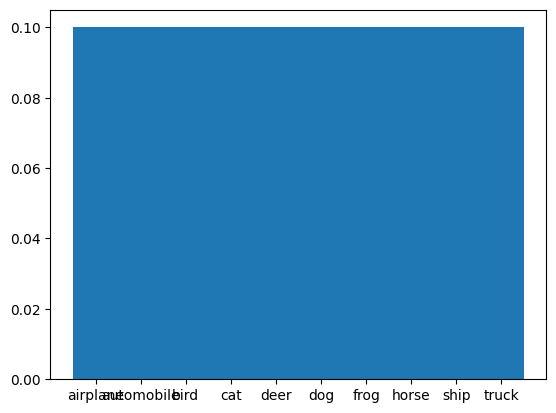

In [61]:
def get_data_statistics(dataset):
    plt.hist(dataset.classes, bins=np.arange(11)-0.5, density=True)

    plt.set_xticks(np.arange(10))
    plt.set_xticklabels(list(dataset.classes))
    plt.set_ylabel('Frequency')
    plt.tick_params(axis='x', rotation=90)
    plt.show()

get_data_statistics(train_dataset_cifar10)

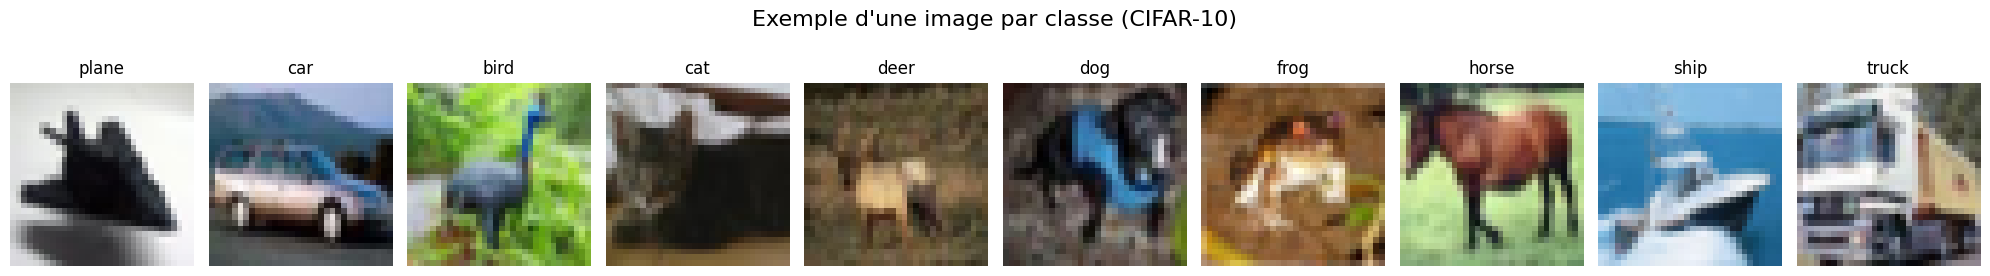


Dimensions d'une image (Tensor) : torch.Size([3, 32, 32])
Plage de valeurs d'un pixel (après ToTensor) : 0.0078 à 0.9961


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Classes from CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Collecter les indices d'une image par classes
num_classes = len(classes)
samples_per_class = 1
indices_to_display = {}

# Parcourir le dataset pour trouver un indice pour chaque classe
for i in range(len(train_dataset_cifar10)):
    _, label = train_dataset_cifar10[i]
    if label not in indices_to_display:
        indices_to_display[label] = i
        if len(indices_to_display) == num_classes:
            break

# Plot
fig, axes = plt.subplots(1, num_classes, figsize=(20, 3))
fig.suptitle("Exemple d'une image par classe (CIFAR-10)", fontsize=16)

for label, index in indices_to_display.items():
    image_tensor, _ = train_dataset_cifar10[index]

    # Convertir le Tensor PyTorch en tableau NumPy pour Matplotlib
    # Le format de CIFAR-10 est (C, H, W) (3, 32, 32), Matplotlib attend (H, W, C)
    image_np = image_tensor.numpy().transpose((1, 2, 0))

    # Affichage
    ax = axes[label]
    ax.imshow(image_np)
    ax.set_title(classes[label])
    ax.axis('off') # Supprimer les axes pour un affichage plus propre

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuster pour le titre
plt.show()

# 4. Afficher le Tensor de l'une des images pour vérification
print(f"\nDimensions d'une image (Tensor) : {image_tensor.shape}")
print(f"Plage de valeurs d'un pixel (après ToTensor) : {image_tensor.min():.4f} à {image_tensor.max():.4f}")

STL10

In [4]:
from torchvision import datasets, transforms
import torch

batch_size = 64 # On réduit la taille du batch car les images sont plus grandes

# Les images STL-10 sont de 96x96, normalisation standard.
transform_stl10 = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.43, 0.43, 0.43], std=[0.27, 0.27, 0.27])])

# Chargement de STL-10
try:
    train_dataset_stl10 = datasets.STL10(root='data_stl10', split='train', transform=transform_stl10, download=True)
    test_dataset_stl10 = datasets.STL10(root='data_stl10', split='test',transform=transform_stl10, download=True)

# Création des DataLoaders
    train_loader_stl10 = torch.utils.data.DataLoader(dataset=train_dataset_stl10, batch_size=batch_size, shuffle=True)
    test_loader_stl10 = torch.utils.data.DataLoader(dataset=test_dataset_stl10, batch_size=batch_size, shuffle=False)

    print("STL-10 chargé avec succès.")
    print(f"Images d'entraînement (étiquetées) : {len(train_dataset_stl10)}")
    print(f"Dimensions de la première image (Tensor) : {train_dataset_stl10[0][0].shape}")

except RuntimeError as e:
    print(f"Erreur lors du téléchargement de STL-10 : {e}")
    print("Veuillez vérifier votre connexion ou si le téléchargement manuel est requis (peu probable pour STL-10).")

100.0%


STL-10 chargé avec succès.
Images d'entraînement (étiquetées) : 5000
Dimensions de la première image (Tensor) : torch.Size([3, 96, 96])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..1.9222947].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5344952..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1859114..1.4575163].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3602034..2

Affichage de 15 images aléatoires du premier batch.


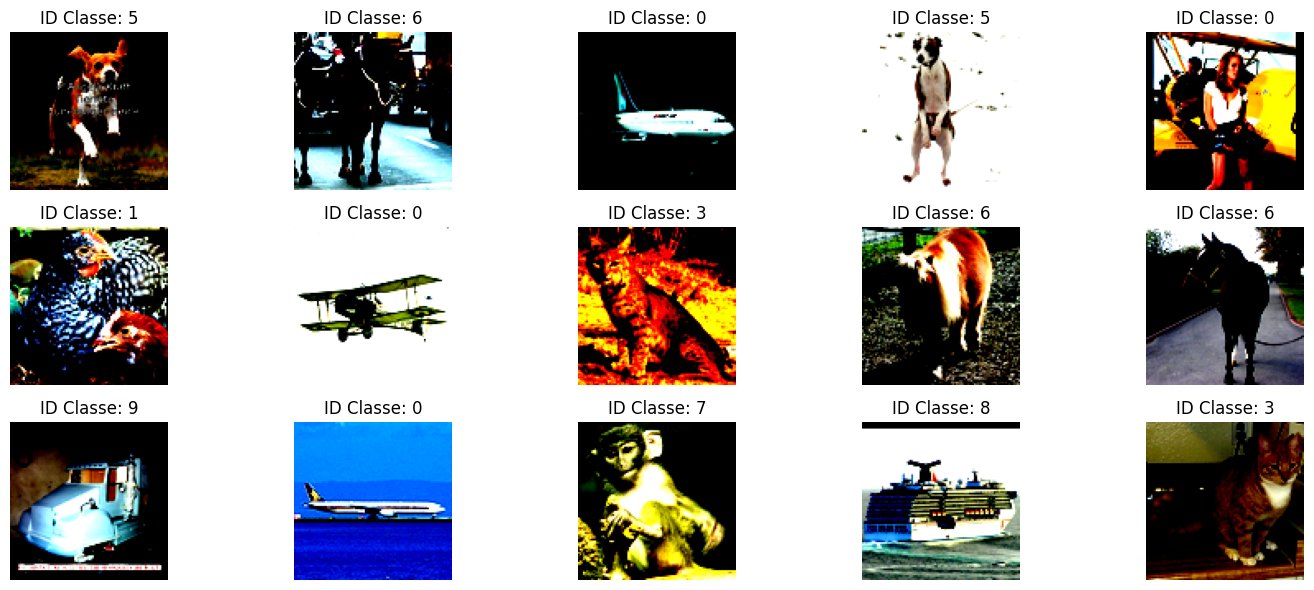


Dimensions d'un lot ImageNet : torch.Size([64, 3, 96, 96])


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Supposons que vous ayez déjà défini un ImageNet-100 ou un autre grand dataset ici
# train_loader = ... (votre DataLoader pour ImageNet-100)

# Récupérer un seul lot du DataLoader
dataiter = iter(train_loader_stl10)
images, labels = next(dataiter)

# Choisir combien d'images afficher (par exemple, 15)
num_to_display = 15

# Créer la grille d'affichage (par exemple, 3 lignes et 5 colonnes)
fig, axes = plt.subplots(3, 5, figsize=(15, 6))
axes = axes.flatten() # Aplatir la grille d'axes pour un parcours facile

# Note : Pour un dataset comme ImageNet-100, vous devez définir votre propre liste de classes
# ou utiliser un dictionnaire pour mapper les IDs (0 à 99) aux noms réels si vous les avez.
# Pour la démo, nous afficherons les IDs numériques.
classes_ids = list(range(100)) # Simple liste des IDs 0 à 99

print(f"Affichage de {num_to_display} images aléatoires du premier batch.")

for i in range(num_to_display):
    # Convertir le Tensor (C, H, W) en NumPy (H, W, C)
    image_np = images[i].numpy().transpose((1, 2, 0))

    ax = axes[i]
    # L'affichage d'ImageNet nécessite généralement une dénormalisation si vous avez appliqué une normalisation
    # Pour l'instant, si vous utilisez seulement ToTensor(), l'affichage est direct.
    ax.imshow(image_np)

    # Afficher l'ID de la classe
    ax.set_title(f"ID Classe: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Vérification des dimensions des données ImageNet
print(f"\nDimensions d'un lot ImageNet : {images.shape}")

In [11]:
# Créons la classe de notre ViT il s'agit la d'une première version naïve avec seulement un encoder.
# J'utilise https://www.geeksforgeeks.org/deep-learning/building-a-vision-transformer-from-scratch-in-pytorch/ 
# Dans un second temps on s'appropriera le code et on complexifiera l'architecture de ce ViT

# Un ViT se compose notamment d'une couche de patch embbeding, positional encoding, Multi head attention layer
# img_size = 32
# in_channels = 3
# embed_dim = 768
# patch_size = 16
# num_heads=8
# depth=6
# mlp_dim=1024
# num_classes=100
# seq_len = (img_size // patch_size) ** 2  # Nombre de patches

class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x
    
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, seq_len):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, embed_dim))  # Adjusted for [CLS] token

    def forward(self, x):
        return x + self.pos_embed
    
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)

    def forward(self, x):
        return self.attn(x, x, x)[0]
    
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, num_classes, embed_dim, num_heads, depth, mlp_dim):
        super().__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, (img_size // patch_size) ** 2)
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(depth)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x)
        return self.mlp_head(x[:, 0])

In [ ]:
model = VisionTransformer(
    img_size=32,  # CIFAR-10 est 32x32
    patch_size=16,
    num_classes=10,  # CIFAR-10 a 10 classes
    embed_dim= 8*32, #8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_liste = []
val_loss_liste = []

def training_loop(train_loader, test_loader):
    #Training loop
    for epoch in range(35):  # Train for 35 epochs
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move to GPU if available
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader.dataset)
        loss_liste.append(epoch_loss)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data, label) in enumerate(test_loader):
                data = data.to(device)
                label = label.to(device)
                recon_batch = model(data)  
                val_loss_batch = criterion(recon_batch, label)
                val_running_loss += val_loss_batch.item()
        
        epoch_val_loss = val_running_loss / len(test_loader.dataset)
        val_loss_liste.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/35], Loss: {epoch_loss}, Val_Loss: {epoch_val_loss}")

In [47]:
training_loop(train_loader=train_loader_cifar10, test_loader= test_loader_cifar10)

Epoch [1/35], Loss: 0.019569054102897644, Val_Loss: 0.018325946140289307
Epoch [2/35], Loss: 0.01815492995738983, Val_Loss: 0.018261816477775573
Epoch [3/35], Loss: 0.018120768384933473, Val_Loss: 0.018259737491607666
Epoch [4/35], Loss: 0.018092904353141783, Val_Loss: 0.018257690382003783
Epoch [5/35], Loss: 0.018075415515899657, Val_Loss: 0.018223948311805724
Epoch [6/35], Loss: 0.018057037253379822, Val_Loss: 0.018215441417694093
Epoch [7/35], Loss: 0.018049740471839906, Val_Loss: 0.0182309654712677
Epoch [8/35], Loss: 0.01804860447883606, Val_Loss: 0.018221061325073243
Epoch [9/35], Loss: 0.018043120799064637, Val_Loss: 0.018227462029457093
Epoch [10/35], Loss: 0.018038274579048157, Val_Loss: 0.01820155155658722
Epoch [11/35], Loss: 0.01803541426181793, Val_Loss: 0.018231032848358156
Epoch [12/35], Loss: 0.018030761861801147, Val_Loss: 0.018199261379241945
Epoch [13/35], Loss: 0.018024349308013915, Val_Loss: 0.018200492668151855
Epoch [14/35], Loss: 0.01802919183254242, Val_Loss: 0

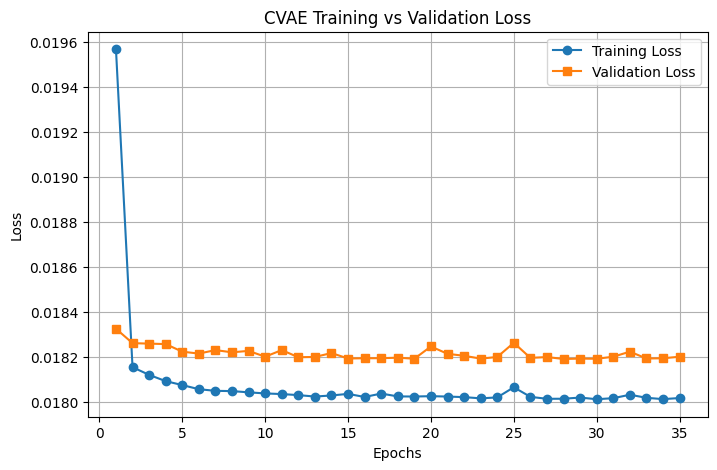

In [48]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 35+1), loss_liste, marker='o', label='Training Loss')
plt.plot(range(1, 35+1), val_loss_liste, marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CVAE Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [49]:
def evaluate_and_visualize(model, test_loader, num_images=15, dataset_name="CIFAR-10"):
    """
    Évalue le modèle sur l'ensemble de validation et affiche les prédictions avec les images.
    
    Args:
        model: Le modèle à évaluer
        test_loader: DataLoader pour l'ensemble de test
        num_images: Nombre d'images à afficher (par défaut 15)
        dataset_name: Nom du dataset pour les classes (par défaut "CIFAR-10")
    """
    
    # Classes CIFAR-10
    classes_cifar10 = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    
    # Dictionnaire pour mapper le nom du dataset aux classes
    classes_dict = {
        "CIFAR-10": classes_cifar10,
    }
    
    classes = classes_dict.get(dataset_name, classes_cifar10)
    
    model.eval()
    all_predictions = []
    all_labels = []
    all_images = []
    
    # Collecter les prédictions
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.append(predicted.cpu())
            all_labels.append(labels.cpu())
            all_images.append(images.cpu())
    
    # Convertir en tenseurs
    all_predictions = torch.cat(all_predictions, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    all_images = torch.cat(all_images, dim=0)
    
    # Calculer l'accuracy globale
    correct = (all_predictions == all_labels).sum().item()
    total = all_labels.size(0)
    accuracy = 100 * correct / total
    
    print(f"\n{'='*70}")
    print(f"RÉSULTATS DE VALIDATION - {dataset_name}")
    print(f"{'='*70}")
    print(f"Accuracy globale: {accuracy:.2f}% ({correct}/{total})")
    print(f"{'='*70}\n")
    
    # Afficher les images avec les prédictions
    num_rows = 3
    num_cols = 5
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 9))
    axes = axes.flatten()
    
    for i in range(min(num_images, len(all_images))):
        image = all_images[i].numpy().transpose((1, 2, 0))
        true_label = all_labels[i].item()
        pred_label = all_predictions[i].item()
        
        # Afficher l'image
        axes[i].imshow(image)
        
        # Couleur verte si correct, rouge sinon
        is_correct = true_label == pred_label
        color = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        
        title = f"{status} Réel: {classes[true_label]}\nPrédit: {classes[pred_label]}"
        axes[i].set_title(title, color=color, fontweight='bold')
        axes[i].axis('off')
    
    # Masquer les subplots non utilisés
    for i in range(min(num_images, len(all_images)), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"Prédictions du modèle ({num_images} images du dataset de validation)", 
                 fontsize=14, y=1.00)
    plt.show()
    
    # Statistiques par classe
    print(f"\nPrécision par classe:")
    print(f"{'-'*70}")
    for class_idx, class_name in enumerate(classes):
        class_mask = all_labels == class_idx
        if class_mask.sum() > 0:
            class_accuracy = (all_predictions[class_mask] == all_labels[class_mask]).sum().item() / class_mask.sum().item()
            class_count = class_mask.sum().item()
            print(f"{class_name:12} : {100*class_accuracy:6.2f}% ({(all_predictions[class_mask] == all_labels[class_mask]).sum().item()}/{class_count})")
    print(f"{'-'*70}\n")
    
    return all_predictions, all_labels, accuracy



RÉSULTATS DE VALIDATION - CIFAR-10
Accuracy globale: 10.00% (1000/10000)



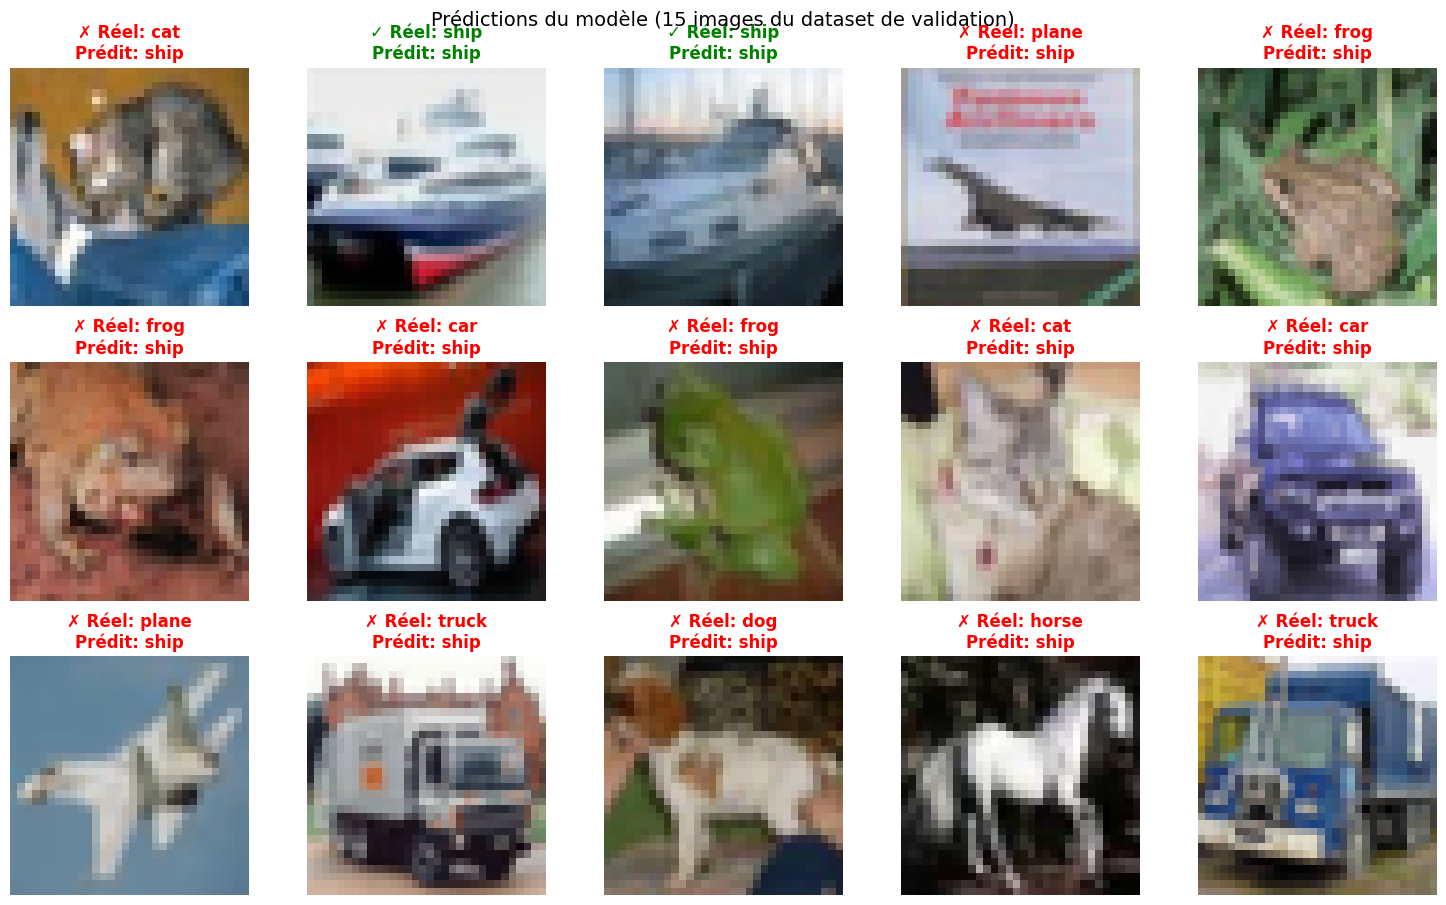


Précision par classe:
----------------------------------------------------------------------
plane        :   0.00% (0/1000)
car          :   0.00% (0/1000)
bird         :   0.00% (0/1000)
cat          :   0.00% (0/1000)
deer         :   0.00% (0/1000)
dog          :   0.00% (0/1000)
frog         :   0.00% (0/1000)
horse        :   0.00% (0/1000)
ship         : 100.00% (1000/1000)
truck        :   0.00% (0/1000)
----------------------------------------------------------------------



In [50]:
# Évaluer et afficher les prédictions du modèle
predictions, true_labels, overall_accuracy = evaluate_and_visualize(
    model=model, 
    test_loader=test_loader_cifar10, 
    num_images=15,
    dataset_name="CIFAR-10"
)
